# Project Cycle 2
## Confidence Intervals and One-Sample Inference
### 範例主題：
1. 比例分析：SadOrHopeless
2. 平均數分析：HowTallAreYouWithoutShoesInMeters

In [9]:
# ===== 0. 載入套件 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display

# 圖表風格設定（讓圖比較乾淨）
sns.set_theme(style="whitegrid")

# ===== 1. 讀取資料 =====
# 請把路徑改成你自己的 CSV 檔位置
file_path = "../data/raw/YRBS_2007.csv"
df = pd.read_csv(file_path)

# 顯示前幾列，確認資料有成功讀進來
print("資料前5列：")
display(df.head())

# 顯示欄位名稱，確認你要分析的變數存在
print("\n所有欄位名稱：")
print(df.columns.tolist())

資料前5列：


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030



所有欄位名稱：
['RaceEth', 'HowOldAreYou', 'WhatIsYourSex', 'InWhatGradeAreYou', 'AreYouHispanicOrLatino', 'WhatIsYourRace', 'HowTallAreYouWithoutShoesInMeters', 'HowMuchDoYouWeighWithoutShoesInKG', 'BicyleHelmetUse', 'SeatBeltUse', 'RidingWithADrinkingDriver', 'DrinkingAndDriving', 'WeaponCarrying', 'GunCarryingPast12Mos', 'WeaponCarryingAtSchool', 'SafetyConcernsAtSchool', 'WereThreatenedOrInjuredWithAWeaponOnSchoolProperty', 'StolenOrDamagedYourProperty', 'PhysicalFighting', 'InjuredIFight', 'PhysicalFightingAtSchool', 'BoyfriendGirlfriendPhysicallyHurt', 'ForcedSexualIntercourse', 'SadOrHopeless', 'ConsideredSuicide', 'MadeASuicidePlan', 'AttemptedSuicide', 'InjuriousSuicide', 'EverCigaretteUse', 'InitiationSmokingWholeCigarette', 'CurrentCigaretteUse', 'SmokedMoreThan10Cigarettes', 'HowObtainedCigarettes', 'SmokeOnSchoolProperty', 'EverSmokedDailyFor30Days', 'EverSmokingCessation', 'CurrentSmokelessTobaccoUse', 'CurrentSmokelessTobaccoOnSchoolProperty', 'CurrentCigarUse', 'EverAlcoholUs


### 研究問題


In [10]:
# 比例分析研究問題
print("研究問題 1：高中生中，感到 sad or hopeless 的比例是否與 0.30 不同？")

# 平均數分析研究問題
print("研究問題 2：高中生的平均身高是否與 1.70 公尺不同？")

研究問題 1：高中生中，感到 sad or hopeless 的比例是否與 0.30 不同？
研究問題 2：高中生的平均身高是否與 1.70 公尺不同？


### 2A. 比例分析變數：SadOrHopeless
##### success = 1
##### failure = 2
##### 其他值視為無效或缺失，先排除

In [11]:
prop_var = "SadOrHopeless"

# 看原始次數分配
print("\nSadOrHopeless 原始編碼次數表：")
print(df[prop_var].value_counts(dropna=False).sort_index())

# 只保留有效值 1 和 2
df_prop = df[df[prop_var].isin([1, 2])].copy()

# 建立二元變數：success=1, failure=0
df_prop["SadOrHopeless_binary"] = np.where(df_prop[prop_var] == 1, 1, 0)

# 計算有效樣本數
n_prop = len(df_prop)

# 顯示處理後結果
print("\n比例分析有效樣本數 n =", n_prop)
print("\n重編碼後次數表：")
print(df_prop["SadOrHopeless_binary"].value_counts().sort_index())

# 缺失/無效值數量
invalid_prop = df[prop_var].isna().sum() + (~df[prop_var].isin([1, 2]) & df[prop_var].notna()).sum()
print("\nSadOrHopeless 缺失或無效值數量 =", invalid_prop)


SadOrHopeless 原始編碼次數表：
SadOrHopeless
1.0    4153
2.0    9692
NaN     196
Name: count, dtype: int64

比例分析有效樣本數 n = 13845

重編碼後次數表：
SadOrHopeless_binary
0    9692
1    4153
Name: count, dtype: int64

SadOrHopeless 缺失或無效值數量 = 196


In [12]:
# ============================================
# 2B. 平均數分析變數：HowTallAreYouWithoutShoesInMeters
# 只保留非缺失且合理的身高值
# ============================================

mean_var = "HowTallAreYouWithoutShoesInMeters"

# 先轉成數值，非數字會變成 NaN
df[mean_var] = pd.to_numeric(df[mean_var], errors="coerce")

# 查看原始資料摘要
print("\n身高原始資料摘要：")
print(df[mean_var].describe())

# 先刪除缺失值
df_mean = df[[mean_var]].dropna().copy()

# 只保留合理身高範圍
df_mean = df_mean[(df_mean[mean_var] >= 1.0) & (df_mean[mean_var] <= 2.5)].copy()

# 計算樣本數
n_mean = len(df_mean)
print("\n平均數分析有效樣本數 n =", n_mean)

# 缺失或無效值數量
invalid_mean = df[mean_var].isna().sum() + ((df[mean_var] < 1.0) | (df[mean_var] > 2.5)).sum()
print("身高缺失或無效值數量 =", invalid_mean)
df_mean.to_csv("yrbs_cleaned.csv", index=False)


身高原始資料摘要：
count    13062.000000
mean         1.694038
std          0.101466
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64

平均數分析有效樣本數 n = 13062
身高缺失或無效值數量 = 979


In [26]:
import pandas as pd
import os

os.makedirs("outputs/tables", exist_ok=True)

eda_summary_table = pd.DataFrame({
    "Statistic": [
        "Sample Size",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum",
        "Missing or Invalid Count"
    ],
    "Value": [
        n_mean,
        df_mean[mean_var].mean(),
        df_mean[mean_var].median(),
        df_mean[mean_var].std(ddof=1),
        df_mean[mean_var].min(),
        df_mean[mean_var].quantile(0.25),
        df_mean[mean_var].quantile(0.75),
        df_mean[mean_var].max(),
        invalid_mean
    ]
})

print(eda_summary_table)
eda_summary_table.to_csv("outputs/tables/eda_summary_table.csv", index=False)

                  Statistic         Value
0               Sample Size  13062.000000
1                      Mean      1.694038
2                    Median      1.680000
3        Standard Deviation      0.101466
4                   Minimum      1.270000
5                        Q1      1.630000
6                        Q3      1.780000
7                   Maximum      2.110000
8  Missing or Invalid Count    979.000000



【EDA】SadOrHopeless 原始編碼次數表
SadOrHopeless
1.0    4153
2.0    9692
NaN     196
Name: count, dtype: int64

【EDA】重編碼後次數表（0=No, 1=Yes）
SadOrHopeless_binary
0    9692
1    4153
Name: count, dtype: int64

【EDA】重編碼後比例表（0=No, 1=Yes）
SadOrHopeless_binary
0    0.700036
1    0.299964
Name: proportion, dtype: float64


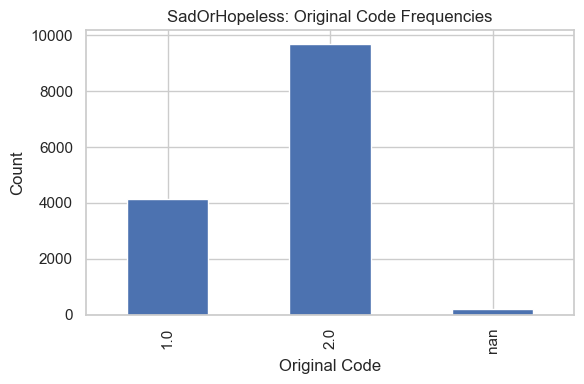

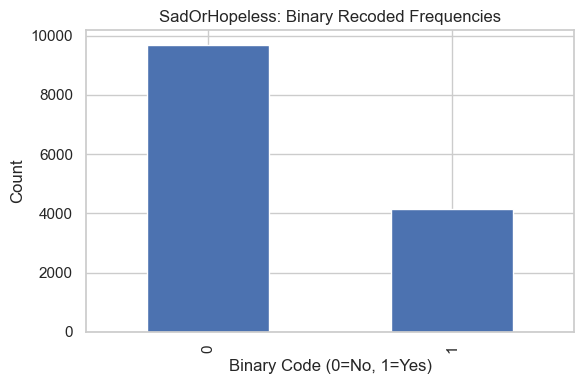

In [15]:
# ============================================
# 3A. 比例變數 EDA
# ============================================

# 原始編碼次數表
orig_freq = df[prop_var].value_counts(dropna=False).sort_index()
print("\n【EDA】SadOrHopeless 原始編碼次數表")
print(orig_freq)

# 重編碼後次數表
binary_freq = df_prop["SadOrHopeless_binary"].value_counts().sort_index()
print("\n【EDA】重編碼後次數表（0=No, 1=Yes）")
print(binary_freq)

# success / failure 比例
prop_table = df_prop["SadOrHopeless_binary"].value_counts(normalize=True).sort_index()
print("\n【EDA】重編碼後比例表（0=No, 1=Yes）")
print(prop_table)

# 長條圖：原始編碼
plt.figure(figsize=(6,4))
orig_freq.plot(kind="bar")
plt.title("SadOrHopeless: Original Code Frequencies")
plt.xlabel("Original Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 長條圖：二元變數
plt.figure(figsize=(6,4))
binary_freq.plot(kind="bar")
plt.title("SadOrHopeless: Binary Recoded Frequencies")
plt.xlabel("Binary Code (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 額外 EDA（老師要求至少一個額外探索）
# 這裡示範：顯示 success 與 failure 百分比
# ============================================

success_count = (df_prop["SadOrHopeless_binary"] == 1).sum()
failure_count = (df_prop["SadOrHopeless_binary"] == 0).sum()

success_prop = success_count / n_prop
failure_prop = failure_count / n_prop

print(f"\nSadOrHopeless = Yes 的樣本比例 = {success_prop:.4f}")
print(f"SadOrHopeless = No 的樣本比例 = {failure_prop:.4f}")


SadOrHopeless = Yes 的樣本比例 = 0.3000
SadOrHopeless = No 的樣本比例 = 0.7000


Interpretation: 
1. 我們先檢查 SadOrHopeless 的原始編碼分布。
2. 接著依照作業規定將 1 視為 success、2 視為 failure。
3. 從二元變數的比例可初步觀察，樣本中感到 sad or hopeless 的比例大約落在哪個範圍。

In [17]:
# ============================================
# 4A. 連續變數 EDA：數值摘要
# ============================================

height = df_mean[mean_var]

print("\n【EDA】身高數值摘要")
print("樣本數 n =", len(height))
print("平均數 mean =", round(height.mean(), 4))
print("中位數 median =", round(height.median(), 4))
print("標準差 sd =", round(height.std(ddof=1), 4))
print("最小值 min =", round(height.min(), 4))
print("第一四分位數 Q1 =", round(height.quantile(0.25), 4))
print("第三四分位數 Q3 =", round(height.quantile(0.75), 4))
print("最大值 max =", round(height.max(), 4))


【EDA】身高數值摘要
樣本數 n = 13062
平均數 mean = 1.694
中位數 median = 1.68
標準差 sd = 0.1015
最小值 min = 1.27
第一四分位數 Q1 = 1.63
第三四分位數 Q3 = 1.78
最大值 max = 2.11


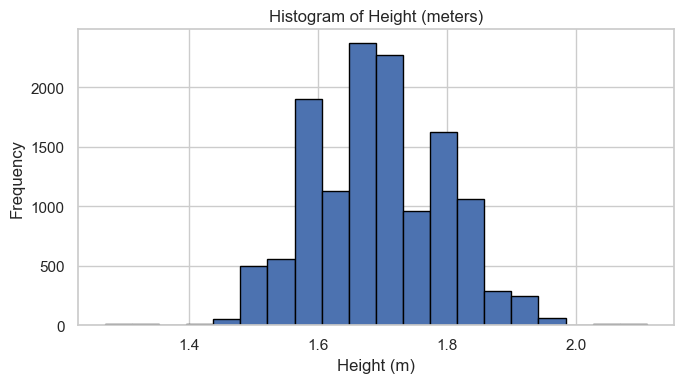

In [18]:
# ============================================
# 4B. Histogram
# ============================================

plt.figure(figsize=(7,4))
plt.hist(height, bins=20, edgecolor="black")
plt.title("Histogram of Height (meters)")
plt.xlabel("Height (m)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

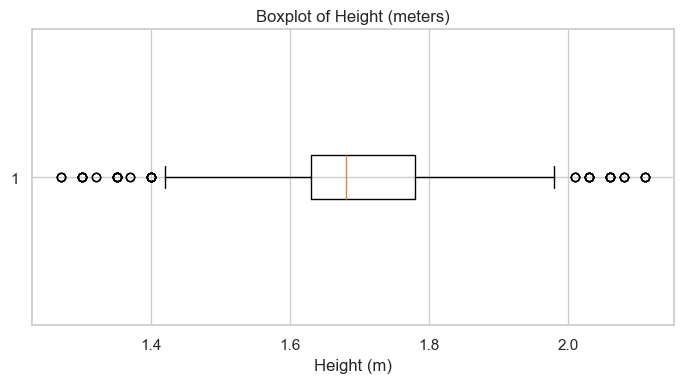

In [19]:
# ============================================
# 4C. Boxplot
# ============================================

plt.figure(figsize=(7,4))
plt.boxplot(height, vert=False)
plt.title("Boxplot of Height (meters)")
plt.xlabel("Height (m)")
plt.tight_layout()
plt.show()

In [20]:
# ============================================
# 4D. 離群值檢查（IQR 方法）
# ============================================

Q1 = height.quantile(0.25)
Q3 = height.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = height[(height < lower_bound) | (height > upper_bound)]

print("\n【EDA】IQR 離群值檢查")
print("下界 =", round(lower_bound, 4))
print("上界 =", round(upper_bound, 4))
print("離群值個數 =", len(outliers))
print("部分離群值：")
print(outliers.head())


【EDA】IQR 離群值檢查
下界 = 1.405
上界 = 2.005
離群值個數 = 52
部分離群值：
112    1.35
604    2.03
763    2.06
771    1.30
829    2.03
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


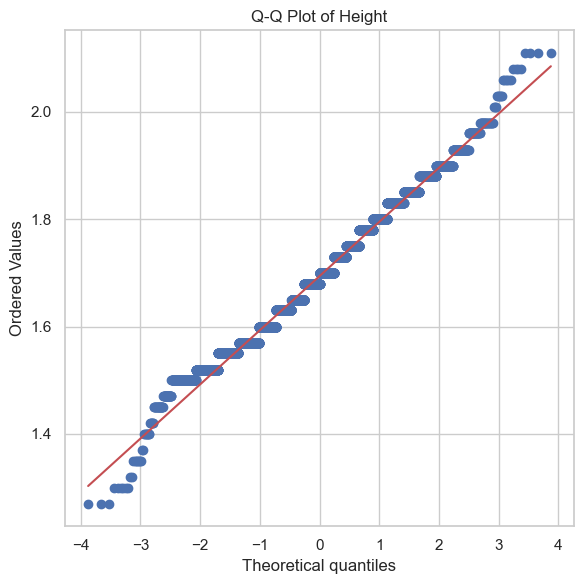

In [21]:
# ============================================
# 4E. 額外 EDA（老師要求至少一個額外探索）
# 這裡示範：常態 Q-Q Plot
# ============================================

plt.figure(figsize=(6,6))
stats.probplot(height, dist="norm", plot=plt)
plt.title("Q-Q Plot of Height")
plt.tight_layout()
plt.show()

intepretation: 
1. 平均數與中位數若接近，表示分布可能沒有非常明顯偏斜。
2. Histogram 可觀察資料大致分布形狀。
3. Boxplot 與 IQR 檢查可幫助判斷是否有離群值。
4. Q-Q Plot 可輔助檢查資料是否近似常態，以支持 t 檢定的合理性。

In [22]:
import pandas as pd
import os

os.makedirs("outputs/tables", exist_ok=True)

eda_summary_table = pd.DataFrame({
    "Statistic": [
        "Sample Size",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum",
        "Missing or Invalid Count"
    ],
    "Value": [
        n_mean,
        df_mean[mean_var].mean(),
        df_mean[mean_var].median(),
        df_mean[mean_var].std(ddof=1),
        df_mean[mean_var].min(),
        df_mean[mean_var].quantile(0.25),
        df_mean[mean_var].quantile(0.75),
        df_mean[mean_var].max(),
        invalid_mean
    ]
})

print(eda_summary_table)
eda_summary_table.to_csv("outputs/tables/eda_summary_table.csv", index=False)

                  Statistic         Value
0               Sample Size  13062.000000
1                      Mean      1.694038
2                    Median      1.680000
3        Standard Deviation      0.101466
4                   Minimum      1.270000
5                        Q1      1.630000
6                        Q3      1.780000
7                   Maximum      2.110000
8  Missing or Invalid Count    979.000000


In [23]:
# ============================================
# 5A. 比例分析：信賴區間 + 單一樣本比例檢定
# H0: p = 0.30
# H1: p != 0.30
# ============================================

p0 = 0.30

# success 次數
x_prop = success_count

# 樣本比例
phat = x_prop / n_prop

print("\n【比例推論】")
print("success 次數 x =", x_prop)
print("樣本數 n =", n_prop)
print("樣本比例 p-hat =", round(phat, 4))
print("虛無假設 benchmark p0 =", p0)

# 95% 信賴區間（Wilson 方法通常比 Wald 更穩定）
ci_low_prop, ci_high_prop = proportion_confint(count=x_prop, nobs=n_prop, alpha=0.05, method='wilson')

print("\n95% 信賴區間 for population proportion:")
print(f"({ci_low_prop:.4f}, {ci_high_prop:.4f})")

# 單一樣本比例 z 檢定（雙尾）
z_stat, p_value_prop = proportions_ztest(count=x_prop, nobs=n_prop, value=p0, alternative='two-sided')

print("\nOne-sample proportion z-test result:")
print("z statistic =", round(z_stat, 4))
print("p-value =", round(p_value_prop, 6))

# 顯著水準
alpha = 0.05

if p_value_prop < alpha:
    print("決策：Reject H0")
else:
    print("決策：Fail to reject H0")


【比例推論】
success 次數 x = 4153
樣本數 n = 13845
樣本比例 p-hat = 0.3
虛無假設 benchmark p0 = 0.3

95% 信賴區間 for population proportion:
(0.2924, 0.3077)

One-sample proportion z-test result:
z statistic = -0.0093
p-value = 0.992601
決策：Fail to reject H0


比例分析解讀：
1. 我們估計的樣本比例 p-hat = 0.3000。
2. 95% 信賴區間為 (0.2924, 0.3077)，表示我們有 95% 信心認為母體中 sad or hopeless 的真實比例落在此區間。
3. 單一樣本比例檢定的 p-value = 0.992601。
4. 因為 p-value >= 0.05，所以不拒絕 H0，表示資料不足以證明母體比例與 0.30 有顯著差異。

In [24]:
# ============================================
# 6A. 平均數分析：信賴區間 + 單一樣本 t 檢定
# H0: mu = 1.70
# H1: mu != 1.70
# ============================================

mu0 = 1.70

n = len(height)
xbar = height.mean()
s = height.std(ddof=1)

print("\n【平均數推論】")
print("樣本數 n =", n)
print("樣本平均數 x-bar =", round(xbar, 4))
print("樣本標準差 s =", round(s, 4))
print("虛無假設 benchmark mu0 =", mu0)

# 95% 信賴區間
# 公式：xbar ± t* × s/sqrt(n)
alpha = 0.05
dfree = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df=dfree)
se = s / np.sqrt(n)

ci_low_mean = xbar - t_critical * se
ci_high_mean = xbar + t_critical * se

print("\n95% 信賴區間 for population mean:")
print(f"({ci_low_mean:.4f}, {ci_high_mean:.4f})")

# 單一樣本 t 檢定
t_stat, p_value_mean = stats.ttest_1samp(height, popmean=mu0)

print("\nOne-sample t-test result:")
print("t statistic =", round(t_stat, 4))
print("p-value =", round(p_value_mean, 6))

if p_value_mean < alpha:
    print("決策：Reject H0")
else:
    print("決策：Fail to reject H0")


【平均數推論】
樣本數 n = 13062
樣本平均數 x-bar = 1.694
樣本標準差 s = 0.1015
虛無假設 benchmark mu0 = 1.7

95% 信賴區間 for population mean:
(1.6923, 1.6958)

One-sample t-test result:
t statistic = -6.7158
p-value = 0.0
決策：Reject H0


平均數分析解讀：
1. 我們估計的樣本平均身高 x-bar = 1.6940 公尺。
2. 95% 信賴區間為 (1.6923, 1.6958)，表示我們有 95% 信心認為母體平均身高落在此區間。
3. 單一樣本 t 檢定的 p-value < 0.001。
4. 因為 p-value < 0.05，所以拒絕 H0，表示母體平均身高與 1.70 公尺有顯著差異。

In [25]:
# ============================================
# 7. 建立推論摘要表
# ============================================

summary_table = pd.DataFrame({
    "Analysis": ["Population Proportion", "Population Mean"],
    "Variable": ["SadOrHopeless", "HowTallAreYouWithoutShoesInMeters"],
    "Sample Estimate": [round(phat, 4), round(xbar, 4)],
    "Benchmark": [p0, mu0],
    "95% CI Lower": [round(ci_low_prop, 4), round(ci_low_mean, 4)],
    "95% CI Upper": [round(ci_high_prop, 4), round(ci_high_mean, 4)],
    "Test Statistic": [round(z_stat, 4), round(t_stat, 4)],
    "p-value": [round(p_value_prop, 6), round(p_value_mean, 6)]
})

print("\n推論摘要表：")
print(summary_table)

# 若你要存成 csv 檔
summary_table.to_csv("inference_summary_table.csv", index=False)


推論摘要表：
                Analysis                           Variable  Sample Estimate  \
0  Population Proportion                      SadOrHopeless            0.300   
1        Population Mean  HowTallAreYouWithoutShoesInMeters            1.694   

   Benchmark  95% CI Lower  95% CI Upper  Test Statistic   p-value  
0        0.3        0.2924        0.3077         -0.0093  0.992601  
1        1.7        1.6923        1.6958         -6.7158  0.000000  


本研究以 YRBS 2007 資料分析學生是否曾感到 sad or hopeless 的比例，以及學生平均身高是否與 benchmark 不同。
EDA 顯示 SadOrHopeless 的 yes 比例約為 0.30，而身高分布大致集中、僅有少數離群值。
推論結果顯示，SadOrHopeless 的母體比例與 0.30 無顯著差異；但平均身高與 1.70 公尺有顯著差異。
整體而言，本研究的推論結果與 EDA 觀察大致一致，但仍應注意樣本代表性與資料限制。